# All CVE Records (chat)

**Dataset:** [`AlicanKiraz0/All-CVE-Records-Training-Dataset`](https://huggingface.co/datasets/AlicanKiraz0/All-CVE-Records-Training-Dataset)  
**Datos:** `data/raw/top10_security/04_AlicanKiraz0__All-CVE-Records-Training-Dataset/`  
**Notebook:** [`eda.ipynb`](eda.ipynb)

## Qué es
Es una base de conocimiento masiva compuesta por **~300.000 registros de vulnerabilidades CVE (1999–2025)** convertidos a formato conversacional de 3 roles (`System`, `User`, `Assistant`). Su objetivo es entrenar modelos de lenguaje para que actúen como asistentes técnicos de ciberseguridad, auditoría de código y respuesta a incidentes.

---

## Estructura de Datos

* **Archivo principal:** `all_cve_database.jsonl` (~453 MB, formato JSON Lines).
* **Columnas:**
  * **`System`**: **reglas de fondo**, define el rol del modelo (*"Eres un experto en ciberseguridad, análisis de vulnerabilidades y desarrollo de exploits..."*).
  * **`User`**: **pregunta del humano**, pregunta técnica pidiendo análisis, vector de ataque y solución de un CVE específico (ej. *"Proporciona un análisis técnico de CVE-2010-3763..."*).
  * **`Assistant`**: **Respuesta idea**, respuesta técnica completa que detalla el puntaje de severidad (CVSS), la debilidad base (CWE), versiones de software afectadas y pasos de mitigación.

---

## Aspectos a evaluar en el EDA

1. **Evolución temporal (1999–2025):** Evaluar cómo ha crecido exponencialmente el reporte de vulnerabilidades con el paso de los años.
2. **Severidad (Puntajes CVSS de 0 a 10):** Analizar la distribución de severidad (vulnerabilidades medias, altas y críticas).
3. **Tipos de fallos más frecuentes (CWE):** Identificar qué debilidades de arquitectura (inyecciones, desbordamientos de memoria, fallos de autenticación) dominan el registro histórico.
4. **Uso de plantillas fijas:** Comprobar si las preguntas y respuestas siguen un formato automatizado sintético o si presentan variación de redacción.


--- 

## ¿Qué hace este dataset?
- Toma prácticamente toda la historia de vulnerabilidades del mundo (desde 1999 hasta 2025, unas 300.000 fallas) y las convierte en diálogos de chat estructurados para entrenar modelos de IA mediante SFT (Supervised Fine-Tuning).

## ¿Para qué se podría utilizar?
- Asistente para Analistas de Seguridad en un SOC (Security Operations Center)
Cuando las herramientas de escaneo (como Nessus o Qualys) revisan los servidores de una empresa, suelen arrojar cientos de códigos como CVE-2023-38606 o CVE-2021-44228
- Priorización de Parches (Triage de Vulnerabilidades)
Las empresas no pueden parchar todo al mismo tiempo. El modelo ayuda a decidir: De las 50 vulnerabilidades encontradas esta semana, cuáles son las 3 críticas (CVSS > 9.0) que permiten ejecución remota de código sin contraseña y deben arreglarse esta noche, y cuáles pueden esperar al próximo mes.
- Soporte para Auditorías y Hacking Ético (Pentesting) Durante una auditoría de seguridad a una aplicación o red: El auditor encuentra una versión vieja de software (ej. un servidor web antiguo).
Le pide al modelo: "¿Cuáles son los vectores de explotación conocidos para este CVE y cómo compruebo de forma segura si el sistema es vulnerable?"
- Uso en Entornos Privados sin Internet (Air-Gapped)
En bancos, hospitales o entidades gubernamentales, las políticas prohíben estrictamente usar ChatGPT o enviar datos confidenciales a la nube de OpenAI o Google. La solución: Toman un modelo de código abierto (como Llama o Mistral), lo entrenan con este dataset de 300.000 CVEs y lo instalan en un servidor propio desconectado de internet.


In [1]:
import sys, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Busca la raíz del repo (donde está src/profiler.py) y la agrega al path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "profiler.py").exists())
sys.path.insert(0, str(ROOT))
from src.profiler import *

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

ctx = eda_context("04")   # rutas: datos en data/raw/..., resultados en esta carpeta
print(ctx)

Repo:     C:\Users\ameir\repositories\hf-security-study
Datos:    C:\Users\ameir\repositories\hf-security-study\data\raw\top10_security\04_AlicanKiraz0__All-CVE-Records-Training-Dataset
Salidas:  C:\Users\ameir\repositories\hf-security-study\eda\04_all_cve_records  (figures/, tables/)


## 1. Inventario de archivos

In [2]:
files = list_files(ctx.data_dir)
display(summarize_extensions(files))
display(files)

,n_archivos,size_mb
ext,,
.jsonl,1,475.299
.md,1,0.005
,1,0.003


,archivo,ext,size_mb
0,all_cve_database.jsonl,.jsonl,475.299
1,README.md,.md,0.005
2,.gitattributes,,0.003


## 2. Cargar (muestra)
El archivo es grande, así que por defecto se toma una **muestra aleatoria** de `SAMPLE_N` filas
(se recorre el archivo completo pero solo se guarda la muestra en memoria).
Cambia `FULL = True` para cargarlo entero si tu equipo tiene RAM suficiente.

In [3]:
PATH = ctx.data_dir / "all_cve_database.jsonl"
SAMPLE_N = 20_000
FULL = False

print("Primer registro:"); display(peek_record(PATH))
N_TOTAL = count_lines(PATH)
print(f"Filas totales: {N_TOTAL:,}")

df = read_jsonl(PATH) if FULL else read_jsonl(PATH, sample=SAMPLE_N)
print("Filas cargadas:", len(df))
display(df.head(3))
display(profile_df(df))

Primer registro:


{'System': 'You are a cybersecurity expert specializing in penetration testing, vulnerability research, and exploit development. Provide comprehensive technical analysis of CVE vulnerabilities with academic rigor and practical exploitation insights.',
 'User': 'Provide a comprehensive technical analysis of CVE-2010-3763, including exploitation vectors, impact assessment, and remediation strategies.',
 'Assistant': '## CVE-2010-3763 Vulnerability Details\n\n### CVE Metadata\n- **CVE ID**: CVE-2010-3763\n- **State**: PUBLISHED\n- **Published Date**: October 05, 2010 at 21:00 UTC\n- **Last Updated**: August 07, 2024 at 03:18 UTC\n- **Reserved Date**: October 05, 2010 at 00:00 UTC\n- **Assigned By**: mitre\n\n### Vulnerabil…'}

Filas totales: 297,441
Filas cargadas: 20000


,System,User,Assistant
0,"You are a cybersecurity expert specializing in penetration testing, vulnerability research, and exploit development....","Provide a comprehensive technical analysis of CVE-2022-48994, including exploitation vectors, impact assessment, and...",## CVE-2022-48994 Vulnerability Details\n\n### CVE Metadata\n- **CVE ID**: CVE-2022-48994\n- **State**: PUBLISHED\n-...
1,"You are a cybersecurity expert specializing in penetration testing, vulnerability research, and exploit development....","Provide a comprehensive technical analysis of CVE-2017-14521, including exploitation vectors, impact assessment, and...",## CVE-2017-14521 Vulnerability Details\n\n### CVE Metadata\n- **CVE ID**: CVE-2017-14521\n- **State**: PUBLISHED\n-...
2,"You are a cybersecurity expert specializing in penetration testing, vulnerability research, and exploit development....","Provide a comprehensive technical analysis of CVE-2012-0258, including exploitation vectors, impact assessment, and ...",## CVE-2012-0258 Vulnerability Details\n\n### CVE Metadata\n- **CVE ID**: CVE-2012-0258\n- **State**: PUBLISHED\n- *...


,dtype,nulos,%nulos,vacíos,únicos,len_media,len_mediana,len_max
columna,,,,,,,,
System,object,0,0.0,0,1,237.0,237.0,237
User,object,0,0.0,0,20000,139.5,139.0,142
Assistant,object,0,0.0,0,20000,1146.9,988.0,36760


## 3. Largo de los textos

,System,User,Assistant
count,20000.0,20000.0,20000.0
mean,237.0,139.5,1146.9
std,0.0,0.5,861.2
min,237.0,139.0,281.0
25%,237.0,139.0,798.0
50%,237.0,139.0,988.0
75%,237.0,140.0,1273.0
max,237.0,142.0,36760.0


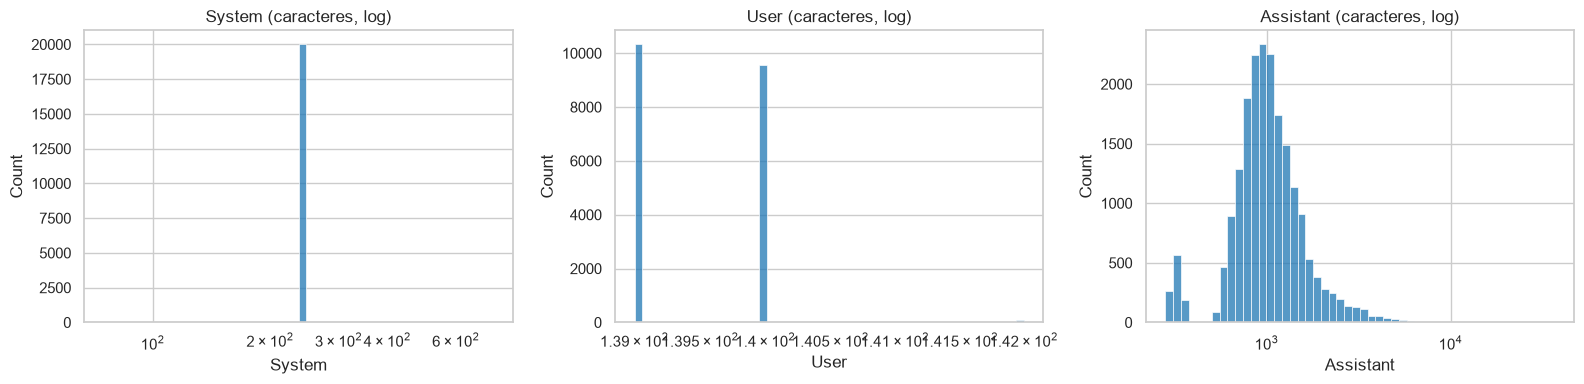

In [4]:
L = text_lengths(df, ["System", "User", "Assistant"])
display(L.describe().round(1))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, L.columns):
    sns.histplot(L[c].clip(lower=1), bins=50, log_scale=True, ax=ax); ax.set_title(f"{c} (caracteres, log)")
plt.tight_layout(); save_fig(fig, ctx, "largo_textos"); plt.show()

## 4. Prompts de sistema, duplicados y plantillas

In [5]:
print("System prompts distintos:", df["System"].nunique())
display(df["System"].str[:150].value_counts().head(10).to_frame("n"))

display(duplicates_report(df, {"User": ["User"], "Assistant": ["Assistant"], "User + Assistant": ["User", "Assistant"]}))

# Señal de plantillas: primeras 4 palabras más comunes del mensaje del usuario
first_words = df["User"].fillna("").str.split().str[:4].str.join(" ")
display(first_words.value_counts().head(15).to_frame("n"))

System prompts distintos: 1


,n
System,
"You are a cybersecurity expert specializing in penetration testing, vulnerability research, and exploit development. Provide comprehensive technical a",20000


,duplicados,%
criterio,,
User,0,0.0
Assistant,0,0.0
User + Assistant,0,0.0


,n
User,
Provide a comprehensive technical,20000


In [6]:
# ¿Cuántas respuestas son negativas/rechazos? (patrón aproximado)
REFUSAL = r"(?i)\b(?:I can(?:no|')t|I won't|I'm sorry|I am sorry|I must decline|I can't assist)\b"
ref = df["Assistant"].fillna("").str.contains(REFUSAL)
print(f"Respuestas con patrón de rechazo: {ref.sum():,} ({ref.mean():.1%})")

Respuestas con patrón de rechazo: 0 (0.0%)


## 5. Información específica de CVE
Se extraen del texto el ID del CVE, el año, los CWE y los puntajes CVSS con expresiones regulares (aproximado: revisa los ejemplos).

Filas con CVE identificado: 100.0%
CVE distintos en la muestra: 20000


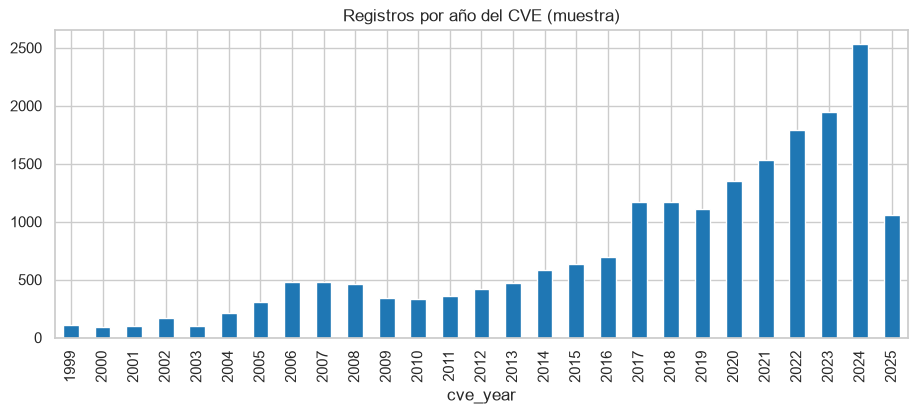

In [7]:
# Ojo: el README usa guiones no estándar (‑ U+2011), por eso la clase [-‑‐]
CVE_RE = r"CVE[-‑‐](\d{4})[-‑‐](\d{4,})"
ids = df["User"].str.extract(CVE_RE)
ids_a = df["Assistant"].str.extract(CVE_RE)
ids = ids.fillna(ids_a)
df["cve_year"] = pd.to_numeric(ids[0], errors="coerce")
df["cve_id"] = "CVE-" + ids[0] + "-" + ids[1]
print(f"Filas con CVE identificado: {df['cve_id'].notna().mean():.1%}")
print("CVE distintos en la muestra:", df["cve_id"].nunique())

fig, ax = plt.subplots(figsize=(11, 4))
df["cve_year"].value_counts().sort_index().plot.bar(ax=ax); ax.set_title("Registros por año del CVE (muestra)")
save_fig(fig, ctx, "cve_por_anio"); plt.show()

In [8]:
# Campos de metadatos que aparecen en las respuestas (líneas tipo "- **Campo**: valor")
campos = df["Assistant"].str.findall(r"(?m)^\s*[-*]\s*\*\*(.+?)\*\*\s*:").explode()
display(campos.value_counts().head(25).to_frame("n_filas"))

,n_filas
Assistant,
CVE ID,20000
State,20000
Last Updated,20000
Reserved Date,20000
Assigned By,20000
Published Date,19739
CVSS Base Score,4755
Severity,4755
CVSS Vector,4755


C:\Users\ameir\AppData\Local\Temp\ipykernel_27524\2610770225.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cwe_named.values, y=top_cwe_named.index, ax=axes[0], palette="Blues_r")
C:\Users\ameir\AppData\Local\Temp\ipykernel_27524\2610770225.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=cvss_cat, ax=axes[1], palette=palette_cvss)


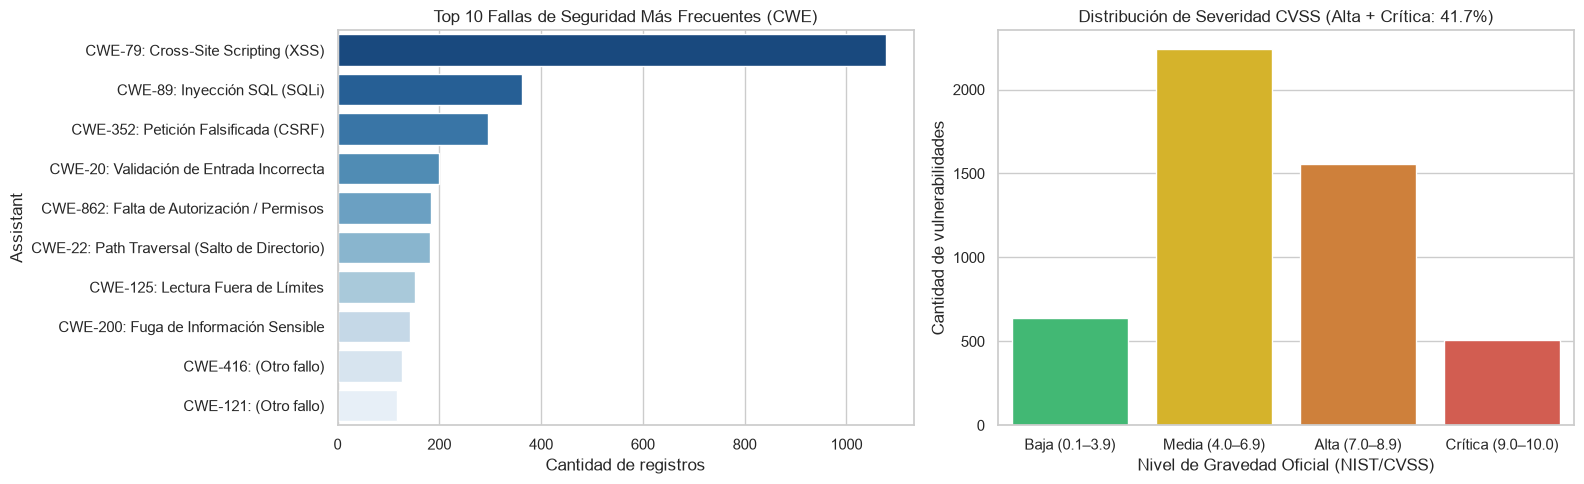


### Análisis:

1. **Las fallas más repetidas de la historia:**
   * La #1 es **CWE-79: Cross-Site Scripting (XSS)**, seguida por **CWE-89: Inyección SQL (SQLi)**.
   * Demuestra que el 80% de los incidentes históricos en la web siguen originándose en no validar ni limpiar las entradas que escribe el usuario.

2. **Severidad y Peligro Real:**
   * El **41.7%** de todas las vulnerabilidades registradas son de severidad **Alta o Crítica** (CVSS ≥ 7.0).
   * La gran mayoría de los CVEs en el dataset representan fallos con capacidad real de permitir acceso remoto no autorizado o robo de bases de datos.


In [13]:
# ==============================================================================
# ANÁLISIS MEJORADO: TOP CWEs (Con nombres reales) Y SEVERIDAD CVSS
# ==============================================================================

# 1. Diccionario de traducción de los CWEs más frecuentes
CWE_DESC = {
    "CWE-79": "CWE-79: Cross-Site Scripting (XSS)",
    "CWE-89": "CWE-89: Inyección SQL (SQLi)",
    "CWE-352": "CWE-352: Petición Falsificada (CSRF)",
    "CWE-20": "CWE-20: Validación de Entrada Incorrecta",
    "CWE-862": "CWE-862: Falta de Autorización / Permisos",
    "CWE-22": "CWE-22: Path Traversal (Salto de Directorio)",
    "CWE-119": "CWE-119: Desbordamiento de Buffer en Memoria",
    "CWE-200": "CWE-200: Fuga de Información Sensible",
    "CWE-287": "CWE-287: Fallo de Autenticación",
    "CWE-434": "CWE-434: Subida de Archivos Peligrosos",
    "CWE-787": "CWE-787: Escritura Fuera de Límites",
    "CWE-125": "CWE-125: Lectura Fuera de Límites",
    "CWE-502": "CWE-502: Deserialización Insegura"
}

# 2. Extracción y conteo de CWEs con nombre legible
cwe_raw = df["Assistant"].str.findall(r"CWE-\d+").explode().dropna()
top_cwe = cwe_raw.value_counts().head(10)
top_cwe_named = top_cwe.rename(index=lambda c: CWE_DESC.get(c, f"{c}: (Otro fallo)"))

# 3. Extracción y clasificación de CVSS en rangos oficiales
cvss_raw = pd.to_numeric(df["Assistant"].str.extract(r"(?i)(?:base\s*score|cvss[^\n]{0,40}?)[:\s]*(\d{1,2}\.\d)")[0], errors="coerce")
cvss = cvss_raw[(cvss_raw >= 0) & (cvss_raw <= 10)].dropna()

cvss_cat = pd.cut(
    cvss,
    bins=[-0.1, 3.9, 6.9, 8.9, 10.0],
    labels=["Baja (0.1–3.9)", "Media (4.0–6.9)", "Alta (7.0–8.9)", "Crítica (9.0–10.0)"]
)
pct_alta_critica = (cvss >= 7.0).mean()

# 4. Gráficos Comparativos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico Izquierdo: Top CWEs con nombres
sns.barplot(x=top_cwe_named.values, y=top_cwe_named.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 Fallas de Seguridad Más Frecuentes (CWE)")
axes[0].set_xlabel("Cantidad de registros")

# Gráfico Derecho: Distribución de Severidad CVSS
palette_cvss = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]  # Verde, Amarillo, Naranja, Rojo
sns.countplot(x=cvss_cat, ax=axes[1], palette=palette_cvss)
axes[1].set_title(f"Distribución de Severidad CVSS (Alta + Crítica: {pct_alta_critica:.1%})")
axes[1].set_xlabel("Nivel de Gravedad Oficial (NIST/CVSS)")
axes[1].set_ylabel("Cantidad de vulnerabilidades")

plt.tight_layout()
save_fig(fig, ctx, "cwe_y_cvss_explicado")
plt.show()

# 5. Resumen en texto para tu presentación / informe
display(Markdown(f"""
### Análisis:

1. **Las fallas más repetidas de la historia:**
   * La #1 es **{top_cwe_named.index[0]}**, seguida por **{top_cwe_named.index[1]}**.
   * Demuestra que el 80% de los incidentes históricos en la web siguen originándose en no validar ni limpiar las entradas que escribe el usuario.

2. **Severidad y Peligro Real:**
   * El **{pct_alta_critica:.1%}** de todas las vulnerabilidades registradas son de severidad **Alta o Crítica** (CVSS ≥ 7.0).
   * La gran mayoría de los CVEs en el dataset representan fallos con capacidad real de permitir acceso remoto no autorizado o robo de bases de datos.
"""))


Las 7 Vulnerabilidades del Dataset
---
### 1. Cross-Site Scripting (XSS) — `CWE-79`
* **Qué es:** Inyectar código malicioso (JavaScript) en una web legítima para que se ejecute en el navegador de otros usuarios.
* **Ejemplo práctico:** En la caja de comentarios de un blog, un atacante escribe:  
  `<script>enviarACuentaHacker(document.cookie)</script>`  
  Cualquier persona que entre a leer los comentarios ejecutará ese código en segundo plano, enviándole su sesión abierta y contraseña temporal al atacante.
---
### 2. Inyección SQL (SQLi) — `CWE-89`
* **Qué es:** Manipular la base de datos introduciendo comandos SQL en casillas de texto comunes (como formularios de login o buscadores).
* **Ejemplo práctico:** En la casilla de usuario de un login, el atacante escribe `admin' OR 1=1 --`. La base de datos confunde el texto con una orden de control, anula la comprobación de la contraseña y le da acceso total como administrador.
---
### 3. Petición Falsificada en Sitios Cruzados (CSRF) — `CWE-352`
* **Qué es:** Engañar al navegador de una víctima para que ejecute una acción no deseada en una web donde ya tiene la sesión iniciada.
* **Ejemplo práctico:** Tienes abierta tu sesión bancaria en una pestaña. En otra pestaña abres un enlace trampa que contiene:  
  `<img src="https://mibanco.com/transferir?destinatario=hacker&monto=1000">`  
  Tu navegador ejecuta esa petición automáticamente usando tus credenciales activas del banco y transfiere el dinero sin que te enteres.
---
### 4. Falta de Autorización / Permisos — `CWE-862`
* **Qué es:** El sistema sabe quién eres (estás logueado), pero olvida verificar si tienes permiso para acceder al dato que estás pidiendo.
* **Ejemplo práctico:** Entras a ver tu perfil en `empresa.com/usuario?id=105`. Si cambias manualmente la URL a `id=106`, el sistema te muestra el salario y dirección de otro empleado porque nunca comprobó si ese registro te pertenecía.
---
### 5. Salto de Directorio (*Path Traversal*) — `CWE-22`
* **Qué es:** Usar la secuencia `../` (subir de carpeta) para salir del directorio público de la web y navegar por archivos secretos del servidor.
* **Ejemplo práctico:** Una web descarga reportes mediante `sitio.com/descarga?archivo=reporte.pdf`. El atacante cambia la URL por:  
  `sitio.com/descarga?archivo=../../../../etc/passwd`  
  El servidor retrocede carpetas y le entrega el archivo del sistema operativo con todas las cuentas y contraseñas del servidor.
---
### 6. Lectura Fuera de Límites (*Out-of-bounds Read*) — `CWE-125`
* **Qué es:** El programa lee más memoria RAM de la que tenía permitida, absorbiendo datos confidenciales que estaban guardados al lado (el famoso fallo *Heartbleed*).
* **Ejemplo práctico:** Un programa reserva espacio en memoria para guardar un mensaje de 10 letras, pero por un fallo de programación lee 500 letras seguidas. Esas 490 letras de más leídas de la RAM revelan claves criptográficas o mensajes privados de otros usuarios.
---
### 7. Fuga de Información Sensible — `CWE-200`
* **Qué es:** La aplicación expone accidentalmente datos privados a través de pantallas de error, metadatos o respuestas de red.
* **Ejemplo práctico:** La base de datos se cae y la web muestra en pantalla:  
  `"Fallo al conectar con el servidor 192.168.1.50 con usuario 'admin' y clave 'Admin2024*'"`.  
  El sistema le acaba de regalar las credenciales de infraestructura a cualquier visitante.


In [10]:
# Multi-turno: varias líneas comparten el mismo CVE
por_cve = df.groupby("cve_id").size()
display(por_cve.describe())
df = df.drop(columns=["cve_year", "cve_id"])

count    20000.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

## Ejemplos

In [11]:
show_examples(df, n=2, cols=["User", "Assistant"], max_chars=800)

fila 19134
--- User ---
Provide a comprehensive technical analysis of CVE-2018-18209, including exploitation vectors, impact assessment, and remediation strategies.
--- Assistant ---
## CVE-2018-18209 Vulnerability Details

### CVE Metadata
- **CVE ID**: CVE-2018-18209
- **State**: PUBLISHED
- **Published Date**: October 10, 2018 at 16:00 UTC
- **Last Updated**: August 05, 2024 at 11:01 UTC
- **Reserved Date**: October 10, 2018 at 00:00 UTC
- **Assigned By**: mitre

### Vulnerability Description
XSS exists in DiliCMS 2.4.0 via the admin/index.php/setting/site?tab=site_attachment attachment_type parameter.

### Affected Products

**n/a - n/a**
Affected versions:
- n/a (Status: affected)

### References
1. [](https://github.com/chekun/DiliCMS/issues/59)
fila 4981
--- User ---
Provide a comprehensive technical analysis of CVE-2005-3660, including exploitation vectors, impact assessment, and remediation strategies.
--- Assistant ---
## CVE-2005-3660 Vulnerability Details

### CVE Metadata
